
# Credit Card Fraud Detection for HDFC Bank
Client Company: HDFC Bank

Dataset URL:https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset

Student Code: GH1038937



## 1. Problem Statement

HDFC Bank handles an enormous number of card transactions on a daily basis. Out of these transactions, there is a possibility of fraudulent transactions. Even if there is a very low probability of fraud in these transactions, there is a great possibility of huge financial losses if these fraudulent transactions occur. Hence, there is a need to detect these fraudulent transactions as early as possible.

In this project, the problem is to predict whether a card transaction is fraudulent or legitimate based on variables related to card transactions. These variables include transaction amount, hour of transaction, type of merchant, whether it is a foreign transaction, location mismatch, device trust score, velocity of recent transaction, and card holder age.

This is a classification problem where:
Target Variable/Labeled Column: `is_fraud`
Class 0: Legitimate transaction
Class 1: Fraudulent transaction

### How this problem is relevant to HDFC Bank:
This can help prevent direct financial losses from fraudulent use of credit cards.
This can help fraud analysts prioritize suspicious transactions.
This can help build trust among customers by reducing fraudulent activity.
This can help speed up response times for actions like blocking, verifying, and reviewing transactions.

### The benefits of solving this problem for the company
If HDFC Bank is better at detecting fraudulent transactions, it can reduce fraud losses for itself while making genuine customer transactions smooth. The model can be employed as a risk scoring component within HDFC Bank's fraud monitoring system. Transactions can be sent for review or blocked based on business rules if they are predicted as fraud.

Since the outcome of the past transactions is known (`is_fraud'), this is a labelled learning problem. It is also a binary classification problem because the number of classes is two. It is also likely to be a class imbalance problem because the number of fraud cases is likely to be significantly smaller than the number of normal cases.


## 2. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 3. Reading Dataset

In [ ]:
df = pd.read_csv('/content/credit_card_fraud_detection.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


## 4. Data Exploration

### 4.1 Data Quality Check and Cleaning

In [ ]:
# column structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
# check missing values before cleaning
missing_values_before = df.isna().sum().to_frame("missing_count")
missing_values_before["missing_percent"] = (missing_values_before["missing_count"] / len(df)) * 100
missing_values_before.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
transaction_id,0,0.0
amount,0,0.0
transaction_hour,0,0.0
merchant_category,0,0.0
foreign_transaction,0,0.0
location_mismatch,0,0.0
device_trust_score,0,0.0
velocity_last_24h,0,0.0
cardholder_age,0,0.0
is_fraud,0,0.0


In [ ]:
# checking duplicate rows
duplicate_value_count = df.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_value_count)

df_clean = df.copy()

# remove full duplicate rows if any
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# separate numeric and categorical column
numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df_clean.select_dtypes(exclude=np.number).columns.tolist()

# fill missing values
for col in numeric_columns:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_columns:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Shape before cleaning :", df.shape)
print("Shape after cleaning  :", df_clean.shape)

Duplicate rows before cleaning: 0
Shape before cleaning : (10000, 10)
Shape after cleaning  : (10000, 10)


In [ ]:
# checking is there any missing values after cleaning
missing_values_after = df_clean.isna().sum().to_frame("missing_count")
missing_values_after["missing_percent"] = (missing_values_after["missing_count"] / len(df_clean)) * 100
display(missing_values_after.sort_values("missing_count", ascending=False))

,missing_count,missing_percent
transaction_id,0,0.0
amount,0,0.0
transaction_hour,0,0.0
merchant_category,0,0.0
foreign_transaction,0,0.0
location_mismatch,0,0.0
device_trust_score,0,0.0
velocity_last_24h,0,0.0
cardholder_age,0,0.0
is_fraud,0,0.0


Description: This process of cleaning verifies the types of variables, counts missing values, removes duplicate records and fills in the remaining missing values based on simple rules based on business logic: median for numerical variables and mode for categorical variables. The quality of the current dataset is good, and this process of cleaning is done to ensure that the analysis starts with a clean dataset with no NaN values.


### 4.2 Target Distribution and Class Imbalance

In [ ]:

df_clean["is_fraud"].value_counts()


,count
is_fraud,
0,9849
1,151


In [ ]:


df_clean["is_fraud"].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,98.49
1,1.51


In [ ]:

fig = px.pie(df_clean, names="is_fraud", title="Fraud vs Non-Fraud Distribution")
fig.show()


Discription: The dataset is highly imbalanced, with a small percentage of fraud cases in the entire dataset. Therefore, accuracy is not a reliable performance measurement in this case. In fraud detection, other performance measurement tools are used, such as recall, precision, and F1-score.

### 4.3 Exploratory Data Analysis

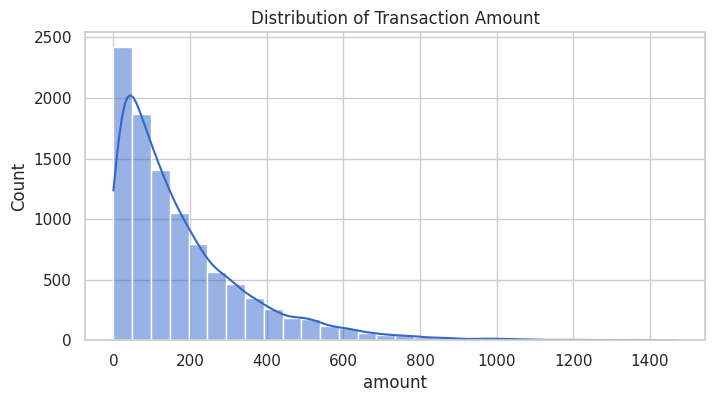

In [ ]:

plt.figure(figsize=(8,4))
sns.histplot(df_clean["amount"], bins=30, kde=True, color='#3366CC')
plt.title("Distribution of Transaction Amount")
plt.show()


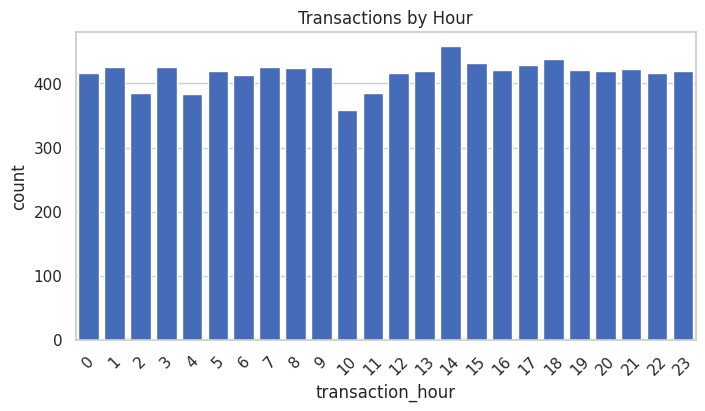

In [ ]:

plt.figure(figsize=(8,4))
sns.countplot(data=df_clean, x="transaction_hour", color='#3366CC')
plt.title("Transactions by Hour")
plt.xticks(rotation=45)
plt.show()


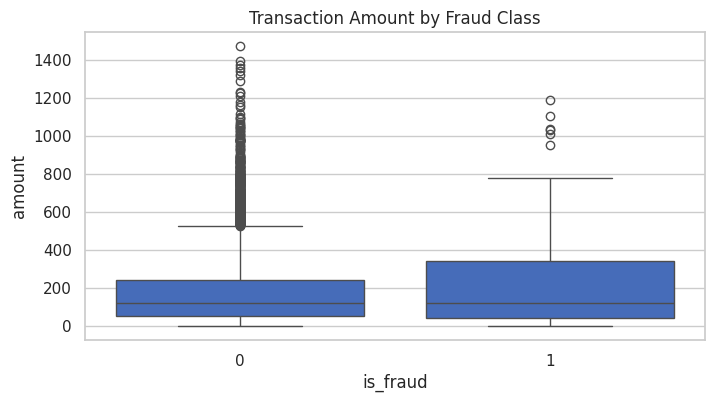

In [ ]:

plt.figure(figsize=(8,4))
sns.boxplot(data=df_clean, x="is_fraud", y="amount", color='#3366CC')
plt.title("Transaction Amount by Fraud Class")
plt.show()


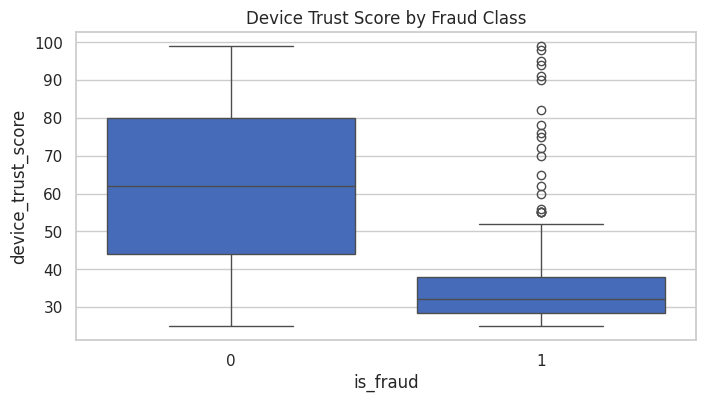

In [ ]:

plt.figure(figsize=(8,4))
sns.boxplot(data=df_clean, x="is_fraud", y="device_trust_score", color='#3366CC')
plt.title("Device Trust Score by Fraud Class")
plt.show()


In [ ]:

fraud_rate_by_category_feature = df_clean.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)
fraud_rate_by_category_feature


,is_fraud
merchant_category,
Grocery,0.020062
Food,0.016722
Travel,0.014573
Electronics,0.012480
Clothing,0.011707


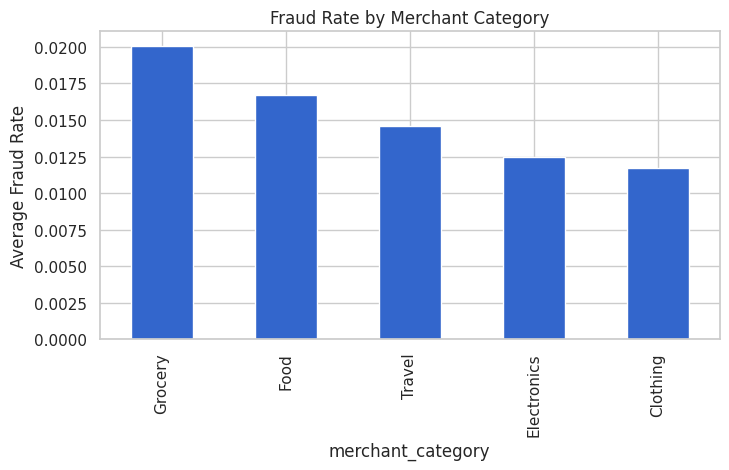

In [ ]:

fraud_rate_by_category.plot(kind="bar", figsize=(8,4), title="Fraud Rate by Merchant Category", color='#3366CC')
plt.ylabel("Average Fraud Rate")
plt.show()


In [ ]:

for col in ["foreign_transaction", "location_mismatch"]:
    temp = pd.crosstab(df_clean[col], df_clean["is_fraud"], normalize="index")
    display(temp)


is_fraud,0,1
foreign_transaction,,
0,0.992352,0.007648
1,0.916155,0.083845


is_fraud,0,1
location_mismatch,,
0,0.991360,0.008640
1,0.915986,0.084014


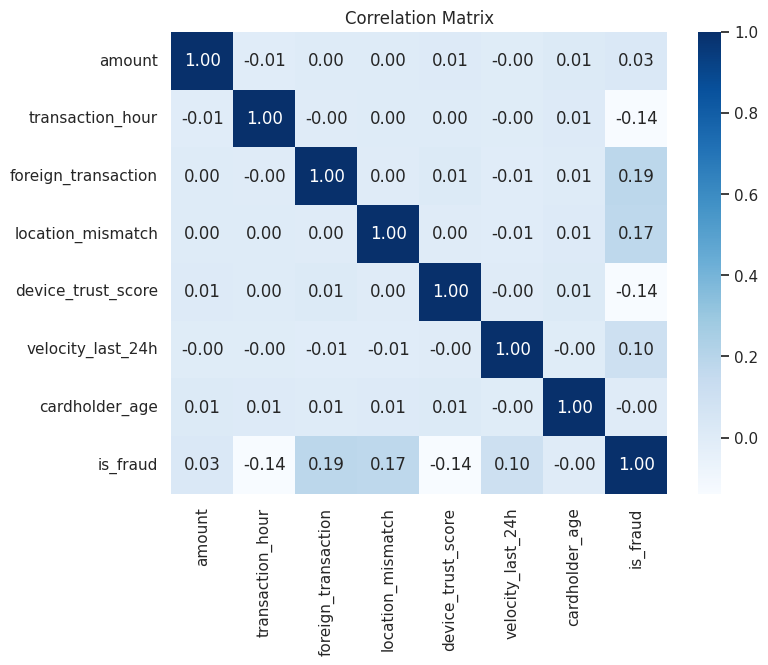

In [ ]:
correl_df = df_clean.drop(columns=["transaction_id"])
correl_matrix = correl_df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8,6))
sns.heatmap(correl_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### 4.4 Data Visualisations by Diff Features

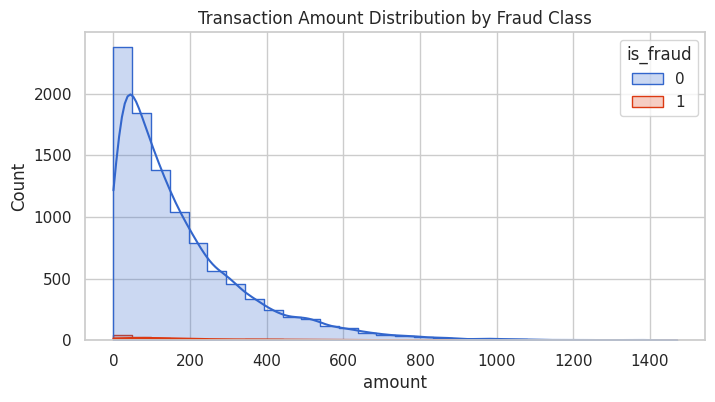

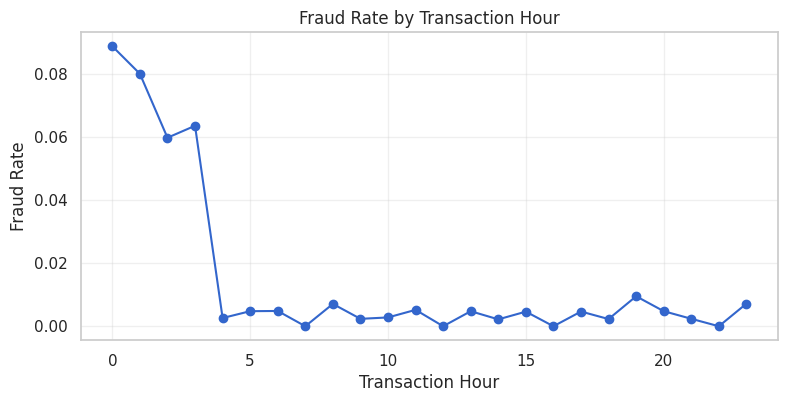

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=df_clean, x="amount", hue="is_fraud", bins=30, kde=True, element="step", palette={0: '#3366CC', 1: '#DC3912'})
plt.title("Transaction Amount Distribution by Fraud Class");
plt.show();

hourly_fraud_rate = df_clean.groupby("transaction_hour")["is_fraud"].mean().sort_index();
plt.figure(figsize=(9,4))
hourly_fraud_rate.plot(marker="o",color='#3366CC')
plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour");
plt.ylabel("Fraud Rate")
plt.grid(True, alpha=0.3)
plt.show()

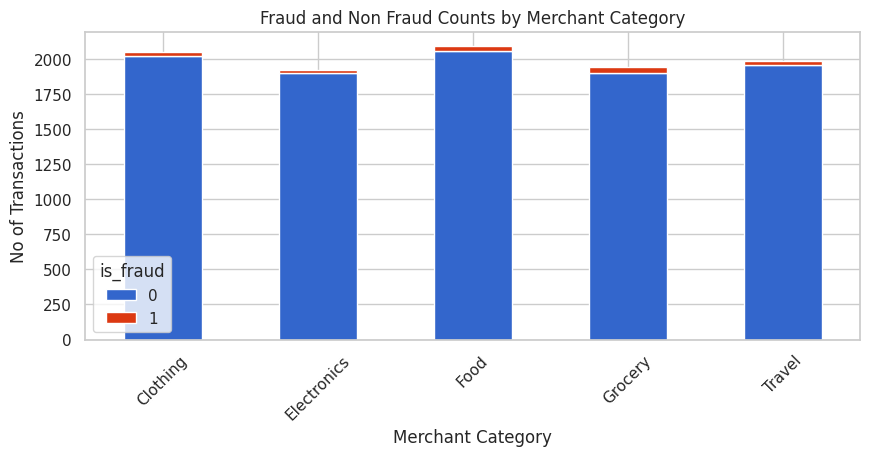

/tmp/ipykernel_27991/607252097.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



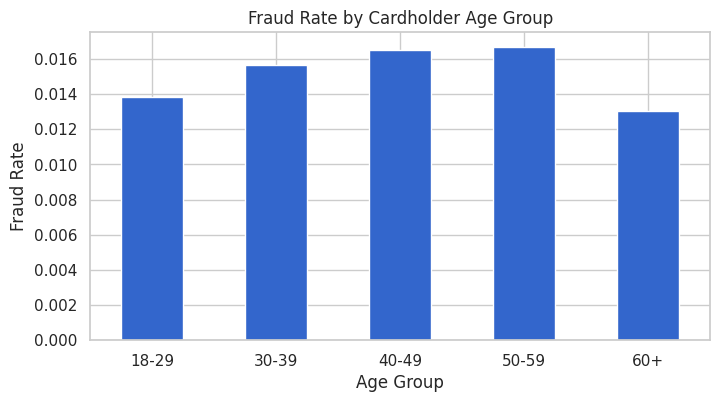

In [ ]:
merchant_count = pd.crosstab(df_clean["merchant_category"], df_clean["is_fraud"])
merchant_count.plot(kind="bar", stacked=True, figsize=(10,4), color=['#3366CC', '#DC3912'])
plt.title("Fraud and Non Fraud Counts by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("No of Transactions")
plt.xticks(rotation=45)
plt.show()

age_bins = [18, 30, 40, 50, 60, 100]
age_labels = ["18-29", "30-39", "40-49", "50-59", "60+"]
df_clean["age_group"] = pd.cut(df_clean["cardholder_age"], bins=age_bins, labels=age_labels, right=False)
age_group_fraud = df_clean.groupby("age_group")["is_fraud"].mean()
plt.figure(figsize=(8,4))
age_group_fraud.plot(kind="bar",color='#3366CC' )
plt.title("Fraud Rate by Cardholder Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.show()

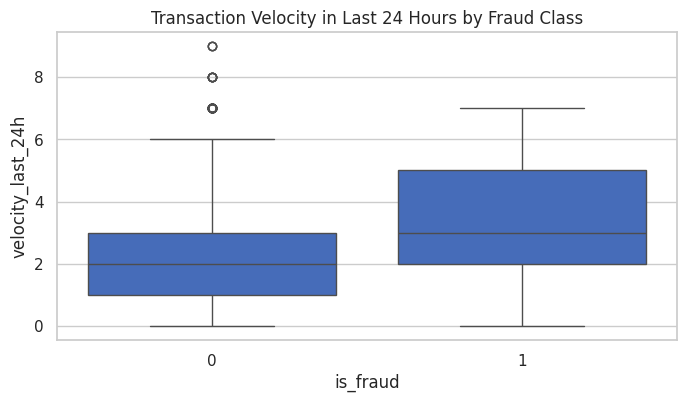

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_clean, x="is_fraud", y="velocity_last_24h",color='#3366CC')
plt.title("Transaction Velocity in Last 24 Hours by Fraud Class")
plt.show()

Description: These additional visualisations help to understand the patterns of frauds more clearly. They show whether fraudulent transactions are related to higher amounts, particular hours of transactions, particular merchant categories, extremely high recent transaction velocity, or particular age groups. This makes the notebook better because it relates the machine learning problem to business understanding before actually building the model.

## 5. Data Preprocessing

### 5.1 Remove unnecessary columns

In [ ]:
df_model = df_clean.copy()
df_model.drop(columns=['transaction_id'], inplace=True)
df_model.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,age_group
0,84.47,22,Electronics,0,0,66,3,40,0,40-49
1,541.82,3,Travel,1,0,87,1,64,0,60+
2,237.01,17,Grocery,0,0,49,1,61,0,60+
3,164.33,4,Grocery,0,1,72,3,34,0,30-39
4,30.53,15,Food,0,0,79,0,44,0,40-49


### 5.2 Define Features and Target

In [ ]:
y = df_model["is_fraud"]
X = df_model.drop(columns=["is_fraud"])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10000, 9)
y shape: (10000,)


### 5.3 Create a Train-Test Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 9)
X_test : (2000, 9)
y_train: (8000,)
y_test : (2000,)


### 5.4 Check column types to indentify how many numerical features and how many categorical

In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
Categorical features: ['merchant_category', 'age_group']


### 5.5 Build Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 6. Test diff models and check accuracy, precision and F1 score

We are using three models for the comparison to verify the accuracy of the models which model is providing the best accuracy for the given problem.
1. Logistic Regression
2. Random Forest Classifier
3. K-Nearest Neighbours

As the data is imbalanced, the primary selection metric for the model will be F1 score. We will also consider the recall score because failing to detect fraudulent transactions can cost the bank a lot.

In [ ]:
results = []
best_model = None
best_model_name = None
best_f1 = -1

### 6.1 Logistic Regression

In [ ]:
linr_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

linr_param_grid = {
    "model__C": [0.1, 1, 10]
}

linr_grid = GridSearchCV(linr_reg_pipeline, linr_param_grid, cv=5, scoring="f1", n_jobs=-1)
linr_grid.fit(X_train, y_train)

linr_best = linr_grid.best_estimator_
linr_pred = linr_best.predict(X_test)
linr_prob = linr_best.predict_proba(X_test)[:, 1]

linr_scores = {
    "Model": "Logistic Regression",
    "Best Params": linr_grid.best_params_,
    "Accuracy": accuracy_score(y_test, linr_pred),
    "Precision": precision_score(y_test, linr_pred, zero_division=0),
    "Recall": recall_score(y_test, linr_pred, zero_division=0),
    "F1": f1_score(y_test, linr_pred, zero_division=0),
}

results.append(lr_scores)
linr_scores

{'Model': 'Logistic Regression',
 'Best Params': {'model__C': 10},
 'Accuracy': 0.9595,
 'Precision': 0.2702702702702703,
 'Recall': 1.0,
 'F1': 0.425531914893617}

### 6.2 Random Forest Classifier

In [ ]:
rndmf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])
rndmf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

rndmf_grid = GridSearchCV(rndmf_pipeline, rndmf_param_grid, cv=5, scoring="f1", n_jobs=-1)
rndmf_grid.fit(X_train, y_train)

rndmf_best = rndmf_grid.best_estimator_
rndmf_pred = rndmf_best.predict(X_test)
rndmf_prob = rndmf_best.predict_proba(X_test)[:, 1]

rndmf_scores = {
    "Model": "Random Forest",
    "Best Params": rndmf_grid.best_params_,
    "Accuracy": accuracy_score(y_test, rndmf_pred),
    "Precision": precision_score(y_test, rndmf_pred, zero_division=0),
    "Recall": recall_score(y_test, rndmf_pred, zero_division=0),
    "F1": f1_score(y_test, rndmf_pred, zero_division=0),
}
results.append(rndmf_scores)
rndmf_scores

{'Model': 'Random Forest',
 'Best Params': {'model__max_depth': 10,
  'model__min_samples_split': 5,
  'model__n_estimators': 100},
 'Accuracy': 0.9935,
 'Precision': 1.0,
 'Recall': 0.5666666666666667,
 'F1': 0.723404255319149}

### 6.3 K-Nearest Neighbours

In [ ]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7],
    "model__weights": ["uniform", "distance"]
}
knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=5, scoring="f1", n_jobs=-1)
knn_grid.fit(X_train, y_train)

knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test)
knn_prob = knn_best.predict_proba(X_test)[:, 1]
knn_scores = {
    "Model": "KNN",
    "Best Params": knn_grid.best_params_,
    "Accuracy": accuracy_score(y_test, knn_pred),
    "Precision": precision_score(y_test, knn_pred, zero_division=0),
    "Recall": recall_score(y_test, knn_pred, zero_division=0),
    "F1": f1_score(y_test, knn_pred, zero_division=0),
}
results.append(knn_scores)
knn_scores

{'Model': 'KNN',
 'Best Params': {'model__n_neighbors': 3, 'model__weights': 'distance'},
 'Accuracy': 0.9915,
 'Precision': 0.8095238095238095,
 'Recall': 0.5666666666666667,
 'F1': 0.6666666666666666}

### 6.4 Compare Model Results

In [ ]:
results_df = pd.DataFrame(results)
# Drop 'ROC_AUC' and 'PR_AUC' columns not require
if 'ROC_AUC' in results_df.columns:
    results_df = results_df.drop(columns=['ROC_AUC'])
if 'PR_AUC' in results_df.columns:
    results_df = results_df.drop(columns=['PR_AUC'])
results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
results_df

,Model,Best Params,Accuracy,Precision,Recall,F1
0,Random Forest,"{'model__max_depth': 10, 'model__min_samples_s...",0.9935,1.000000,0.566667,0.723404
1,KNN,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.9915,0.809524,0.566667,0.666667
2,Logistic Regression,{'model__C': 10},0.9595,0.270270,1.000000,0.425532
3,Logistic Regression,{'model__C': 10},0.9595,0.270270,1.000000,0.425532


In [ ]:
best_model_name = results_df.loc[0, "Model"]
print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: Random Forest


## 7. Final Model Assessment on Test Set

In [ ]:
model_lookup = {
    "Logistic Regression": (linr_best, linr_pred, linr_prob),
    "Random Forest": (rndmf_best, rndmf_pred, rndmf_prob),
    "KNN": (knn_best, knn_pred, knn_prob)
}
best_model, best_pred, best_prob = model_lookup[best_model_name]
print(classification_report(y_test, best_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.57      0.72        30

    accuracy                           0.99      2000
   macro avg       1.00      0.78      0.86      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
cm = confusion_matrix(y_test, best_pred)
cm

array([[1970,    0],
       [  13,   17]])

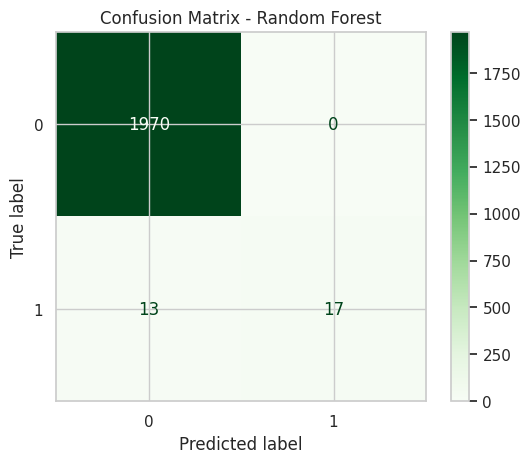

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, cmap='Greens')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 8. Feature Importance

,Feature,Importance
1,num__transaction_hour,0.252335
4,num__device_trust_score,0.250894
2,num__foreign_transaction,0.134281
5,num__velocity_last_24h,0.123454
3,num__location_mismatch,0.115683
0,num__amount,0.048206
6,num__cardholder_age,0.030786
8,cat__merchant_category_Electronics,0.006793
10,cat__merchant_category_Grocery,0.005389
11,cat__merchant_category_Travel,0.005362


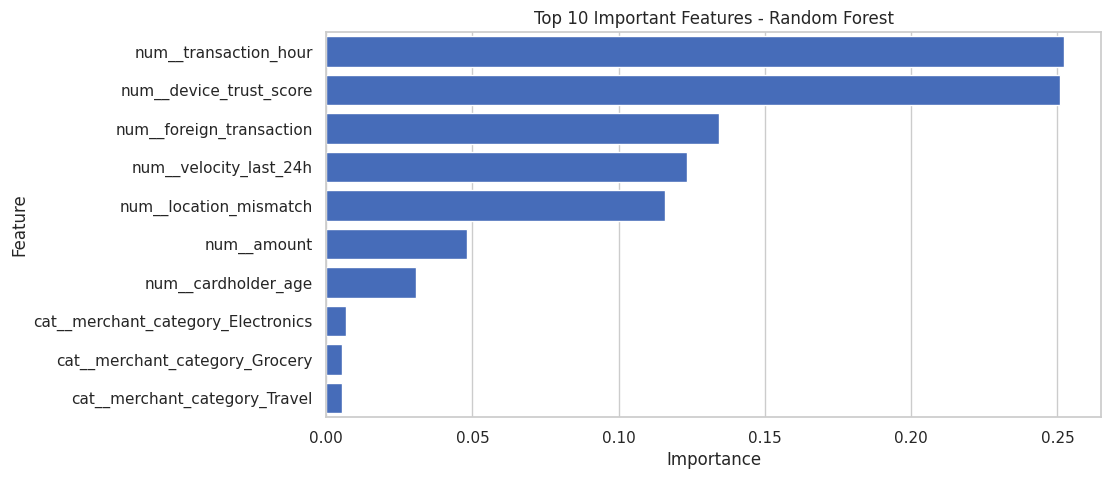

In [ ]:
if best_model_name == "Random Forest":
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importances = best_model.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    display(importance_df.head(10))

    plt.figure(figsize=(10,5))
    sns.barplot(data=importance_df.head(10), x="Importance", y="Feature",color='#3366CC')
    plt.title("Top 10 Important Features - Random Forest")
    plt.show()
else:
    print("Feature importance plot is most direct for Random Forest.");

## 9. Final Discussion and Recommendations


### Strengths of this Pipeline
It follows an end-to-end machine learning process.
It compares multiple classification models.
It treats categorical and numeric variables correctly.
It uses the correct evaluation metric for the imbalanced fraud dataset.

### Limitations
The dataset is relatively small.
The dataset may not fully represent the complexity of a real banking scenario.
Real-world fraud systems may have additional signals such as IP address information, card history, channel information and geo information.
Class imbalance is still a challenge.

The performance may not represent real-time performance in a notebook setting.

### Business Implications for HDFC Bank
This model could potentially be used for a fraud risk scoring system. If a transaction is classified as a higher risk, it could be: blocked, sent for OTP verification and sent for manual analyst review.

### Recommendation
The ultimate recommendation will be based on the best test results. However, generally speaking, HDFC Bank will want a model that has a strong balance between recall and precision, with a bias towards recall, since missing a potential fraud transaction is costly.

### Deployment Decision
This model will not be deployed based on this notebook. Before deployment, the bank will need to perform a variety of steps, including validation on larger and newer data, threshold tuning, fairness, explainability and monitoring for drift.
